# (노트) 기울기소멸, 추천시스템

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

## 기울기소멸 

### 고요속의 외침 

`-` https://www.youtube.com/watch?v=ouitOnaDtFY

`-` 중간에 한명이라도 잘못말한다면.. 

### 정의 

`-` In machine learning, the vanishing gradient problem is encountered when training artificial neural networks with gradient-based learning methods and backpropagation. 

### 이해 

`-` 당연한거 아닌가? 
- 그래디언트 기반의 학습(그래디언트 기반의 옵티마이저): 손실함수의 기울기를 통하여 업데이트 하는 방식
- 역전파: 손실함수의 기울기를 구하는 테크닉(체인룰 + $\alpha$). 구체적으로는 (1) 손실함수를 여러단계로 쪼개고 (2) 각 단계의 미분을 각각 구하고 (3) 그것들을 모두 곱하여 기울기를 계산한다. 
- 0근처의 숫자를 계속 곱하면 터지거나 0으로 간다. (사실 안정적인 기울기가 나올거라고 보는것이 이상한것임) 

In [206]:
import numpy as np

In [207]:
grads = np.random.uniform(low=-2,high=2,size=100)
grads

array([ 0.18688288,  0.43450847, -0.87513215,  1.35976661, -1.67602921,
       -1.94881797,  0.28000878, -0.07982773,  0.41098101,  1.44913431,
        1.42155413,  0.30179395, -1.11750978, -1.03629995,  1.73194045,
        1.30429018, -1.85441508, -0.23849127,  1.69550035,  1.08930237,
        0.61166949, -1.55165233,  1.35400582, -0.79701747,  0.80542101,
       -1.63942602,  1.5169811 , -0.99256516,  1.12927938, -0.60001878,
       -0.79629782, -1.41639694, -1.60737528, -0.810134  ,  1.46868468,
        0.80995697, -0.01861418,  1.870188  ,  0.7237886 ,  1.94490223,
        0.30018531,  0.7239008 , -1.49830624,  0.35257188,  1.54092802,
        0.37818125,  1.85990611, -1.03105941,  0.5865016 , -1.98180695,
       -0.27474677,  0.88501944,  0.47957049,  1.97015467,  1.18178691,
        1.35343833,  1.84192922, -0.16687519, -0.63599077,  1.78165492,
       -1.38607268, -0.6363796 ,  1.26337952, -1.82063191,  1.92715124,
        0.56908745, -1.44857969, -0.44694881,  1.12397453,  0.81

In [208]:
grads.prod()

-4.231809904440714e-11

- 기울기가 소멸함 

In [209]:
grads = np.random.uniform(low=-3,high=3,size=100)
grads.prod()

16676775121011.598

- 기울기가 폭발함 

In [210]:
grads = np.random.uniform(low=-3,high=3,size=100)
grads.prod()

-504691.96433542186

In [244]:
grads = np.random.uniform(low=-1,high=3.5,size=100)
grads.prod()

-5.898185033226975e-06

`-` 도깨비: 기울기가 소멸하기도 하고 터지기도 한다. 

### 해결책 (기울기 소멸에 대한 해결책) 

> Note: 잘 정리되어있는게 없어서 제 머리속에서 정리했습니다. 부정확할수 있어요. 

`-` 개념 
- 데이터 $\to$ (아키텍처, 손실함수, 역전파, 업데이트) 

`-` Multi-level hierarchy 
- 여러층을 쪼개서 학습하자 $\to$ 어떻게?... 사전학습, 층별학습. 
- 기울기소실문제를 해결하여 딥러닝을 유행시킨 태초의 방법임. 
- 입력자료의 전처리도 여기에 해당함 
- 결국 입력자료를 바꾼뒤에 학습하는 형태 

`-` Faster hardware 
- GPU를 중심으로 한 테크닉. 
- 근본적인 문제해결은 아니라는 힌튼의 비판. 
- CPU를 쓸때보다 GPU를 쓰면 약간 더 깊은 모형을 학습할 수 있다 정도? 

`-` ResNet 
- 훌륭한 접근법중 하나임 
- 아키텍처를 변경하는 방법이지만, 사실상 손실함수를 스무딩 시켜버리는 기법으로 이해해도 된다. 
- 숏컷이라는 아키텍처를 추가하여 이리저리 실험해보니까 손실함수가 스무딩 되었다! <-- 이런게 아니라.. 
- 손실함수를 스무딩하기 위해서는 층별의 차이(residual)만 학습하는게 유리할것 같다. 그런데 그것을 위한 효과를 주기 위해 아키텍처를 설계하려면 단지 숏컷을 만들기만 하면 된다. <-- 이런 모티브였을 것이다.. 

`-` 활성화함수의 변경 
- 렐루의 개발 $\to$ 특정노드가 죽음 $\to$ 리키렐루의 개발 

`-` 배치정규화 
- 어쩌다보니 되는 것. 
- 배치정규화는 공변량 쉬프트를 잡기위한 방법임. 그런데 기울기소멸에도 효과가 있음. 현재는 기울기 소멸에 대한 해결책으로 빠짐없이 언급되는 내용. 하지만 2015년의 원래 논문에서는 기울기소멸에 대한 언급없음 (https://arxiv.org/pdf/1502.03167.pdf)
- 심지어 배치정규화는 오버피팅을 잡는것에도 효과가 있음 (이것은 논문에 언급있음) 

`-` **기울기를 안구하면 안되나?**
- 베이지안 최적화기법: (https://arxiv.org/pdf/1807.02811.pdf) $\to$ GPU를 어떻게써? $\to$ 진짜 엄청느려요.. 지옥입니다.. 
- 강화학습? 

## 딥러닝 + 머신러닝 공부를 위한 교재 

`-` 기계학습, 오일석 (http://www.yes24.com/Product/Goods/57537091) 
- 좋은 교재에요.. 
- 딥러닝 초급내용을 커버할 수 있습니다.. 

`-` 심층학습, 이안굿펠로우 (https://www.aladin.co.kr/shop/wproduct.aspx?ItemId=171345378) 
- 이안굿펠로우는 GAN을 만든사람입니다. 
- 거의 표준임. 
- 번역상태가 너무 너무 안좋아요. 

`-` 머신러닝교재들 
- 패턴인식: 
- Element of Statistical Learning 

## 추천시스템 

### import 

In [3]:
import torch 
import matplotlib.pyplot as plt

In [4]:
from fastai.collab import * 
from fastai.tabular.all import * 

### data (시뮬레이션) 

In [5]:
user = list(range(100))
item = list(range(20))
_lst = [[0,0,4.2]]

In [6]:
def f(u,i): 
    if u<=50 and i<10: 
        return np.random.randn(1)[0]*0.2+4 
    elif u<=50 and i>=10:
        return np.random.randn(1)[0]*0.2+1 
    elif u>50 and i<10:
        return np.random.randn(1)[0]*0.2+1 
    elif u>50 and i>=10:
        return np.random.randn(1)[0]*0.2+4 
        
for u in user:
    _item = np.random.randint(0,20,(10,)).tolist()
    for i in _item:
        _lst.append([u,i,f(u,i)])

In [7]:
_df1=pd.DataFrame(_lst[1:],columns=['user','item','rating'])
_df1

,user,item,rating
0,0,11,1.075972
1,0,15,1.000423
2,0,6,3.964191
3,0,3,3.701276
4,0,14,0.948137
...,...,...,...
995,99,13,4.276147
996,99,17,4.301289
997,99,16,3.997453
998,99,1,1.171996


In [8]:
['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)]

['커피0',
 '커피1',
 '커피2',
 '커피3',
 '커피4',
 '커피5',
 '커피6',
 '커피7',
 '커피8',
 '커피9',
 '홍차0',
 '홍차1',
 '홍차2',
 '홍차3',
 '홍차4',
 '홍차5',
 '홍차6',
 '홍차7',
 '홍차8',
 '홍차9']

In [9]:
_df2 = pd.DataFrame({'item':list(range(20)), 'item_name':['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)]})
_df2

,item,item_name
0,0,커피0
1,1,커피1
2,2,커피2
3,3,커피3
4,4,커피4
5,5,커피5
6,6,커피6
7,7,커피7
8,8,커피8
9,9,커피9


In [10]:
df= _df1.merge(_df2).sort_values('user') 
df

,user,item,rating,item_name
0,0,11,1.075972,홍차1
348,0,16,1.085360,홍차6
251,0,13,1.181550,홍차3
398,0,12,0.969057,홍차2
454,0,9,3.934896,커피9
...,...,...,...,...
101,99,15,3.998422,홍차5
488,99,9,1.256416,커피9
951,99,17,4.301289,홍차7
296,99,13,3.690720,홍차3


### data (load) 

`-` 가짜 자료 

### user-item matrix 

In [11]:
matdf=pd.DataFrame([[None]*20]*100,columns=['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)])
matdf

,커피0,커피1,커피2,커피3,커피4,커피5,커피6,커피7,커피8,커피9,홍차0,홍차1,홍차2,홍차3,홍차4,홍차5,홍차6,홍차7,홍차8,홍차9
0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
96,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
97,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
98,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


`-` 아래와 같은 매트릭스를 고려하자. 

In [12]:
for (i,j) in zip(df.user.to_list(), df.item.to_list()):
    matdf.iloc[i,j]=df.query('user == @i and item == @j')['rating'].to_list()[0]

In [256]:
matdf

,커피0,커피1,커피2,커피3,커피4,커피5,커피6,커피7,커피8,커피9,홍차0,홍차1,홍차2,홍차3,홍차4,홍차5,홍차6,홍차7,홍차8,홍차9
0,None,None,4.157269,3.701276,None,None,3.964191,None,None,3.934896,None,1.075972,0.969057,1.18155,0.948137,1.000423,1.08536,None,None,None
1,None,None,4.293147,4.129758,None,None,None,None,None,None,None,0.911054,None,1.087587,0.913438,None,0.842945,None,0.935546,1.167047
2,4.040331,None,None,4.072081,None,3.870153,None,4.103571,None,None,0.561295,None,None,0.904302,None,0.80608,None,None,None,None
3,None,3.662075,4.163859,3.780277,None,4.238297,None,None,4.449407,3.817098,None,0.80868,1.117944,None,0.733432,None,None,None,None,None
4,3.734296,3.750548,None,4.272591,None,None,None,4.175212,None,None,None,0.832415,None,None,0.843098,None,None,1.240576,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.908182,None,1.107076,None,None,1.229219,1.034485,0.960028,None,None,None,None,None,3.750283,None,None,None,3.904733,None,4.149773
96,None,0.93733,0.851605,None,1.194331,1.102694,None,1.344051,None,None,None,None,None,None,3.825828,None,4.084354,4.193276,None,None
97,None,1.206995,None,None,None,None,None,1.238132,None,None,3.68984,None,4.000226,3.992863,4.308006,3.74253,None,4.259089,None,3.89491
98,None,None,None,None,None,1.190105,None,None,1.214272,None,4.133368,None,4.063283,3.852684,None,4.126349,None,4.225108,None,None


In [255]:
matdf.loc[50]

커피0    3.911582
커피1        None
커피2    4.130162
커피3        None
커피4    4.138052
커피5    3.939777
커피6        None
커피7        None
커피8    4.406338
커피9    3.708746
홍차0        None
홍차1    0.900757
홍차2        None
홍차3        None
홍차4        None
홍차5        None
홍차6        None
홍차7    0.984615
홍차8    1.142929
홍차9        None
Name: 50, dtype: object

In [253]:
matdf.loc[1]

커피0    3.911582
커피1        None
커피2    4.130162
커피3        None
커피4    4.138052
커피5    3.939777
커피6        None
커피7        None
커피8    4.406338
커피9    3.708746
홍차0        None
홍차1    0.900757
홍차2        None
홍차3        None
홍차4        None
홍차5        None
홍차6        None
홍차7    0.984615
홍차8    1.142929
홍차9        None
Name: 50, dtype: object

In [128]:
matdf.iloc[14,:]

커피0    3.768687
커피1        None
커피2    3.798913
커피3        None
커피4        None
커피5    3.988476
커피6    3.971965
커피7    3.750718
커피8        None
커피9        None
홍차0        None
홍차1        None
홍차2        None
홍차3        None
홍차4        None
홍차5    0.871768
홍차6    1.056958
홍차7    0.914648
홍차8        None
홍차9        None
Name: 14, dtype: object

`-` None의 값을 추론하는 방법? 

### df $\to$ dls 

In [14]:
dls=CollabDataLoaders.from_df(df,bs=100) # df의 형식: 첫번째열을 사용자인덱스, 두번째열은 아이템인덱스, 세번째열은 rating, 네번째열은 아이템이름으로 약속

In [15]:
dls.items

,user,item,rating,item_name
218,45,15,1.208396,홍차4
969,39,5,3.878503,커피4
775,94,11,3.963973,홍차0
327,61,3,1.045878,커피2
396,97,17,4.084354,홍차6
...,...,...,...,...
369,37,17,0.876350,홍차6
945,90,18,3.748642,홍차7
203,5,15,0.843098,홍차4
690,25,1,4.110631,커피0


### learn 

In [16]:
dls.show_batch()

,user,item,rating
0,92,0,1.055032
1,68,0,0.916732
2,79,15,4.136414
3,10,19,1.105011
4,16,19,0.901475
5,77,14,3.947149
6,61,2,0.993542
7,67,8,0.857661
8,54,17,4.070119
9,83,8,1.604831


In [17]:
lrnr = collab_learner(dls,n_factors=2,y_range=(0,5))
lrnr.fit(30,0.01)

epoch,train_loss,valid_loss,time
0,2.265612,2.323539,00:00
1,2.230480,2.322987,00:00
2,2.191929,2.294235,00:00
3,2.138506,2.213424,00:00
4,2.061635,2.057869,00:00
5,1.956728,1.822089,00:00
6,1.819793,1.519095,00:00
7,1.655085,1.183534,00:00
8,1.471749,0.859012,00:00
9,1.282727,0.582412,00:00


In [18]:
lrnr.show_results()

,user,item,rating,rating_pred
0,24.0,4.0,4.108067,3.963889
1,29.0,18.0,0.802562,0.985309
2,5.0,4.0,4.272591,3.996555
3,46.0,2.0,4.080017,3.864990
4,3.0,16.0,0.700815,0.851171
5,36.0,8.0,4.325551,3.805528
6,10.0,18.0,0.809472,0.953938
7,13.0,4.0,4.123691,4.027287
8,91.0,11.0,4.398950,3.786829


In [19]:
lrnr.model

EmbeddingDotBias(
  (u_weight): Embedding(101, 2)
  (i_weight): Embedding(21, 2)
  (u_bias): Embedding(101, 1)
  (i_bias): Embedding(21, 1)
)

In [20]:
lrnr.model.i_weight.weight.to("cpu").detach()

tensor([[ 0.0098,  0.0051],
        [ 1.1329,  0.9344],
        [ 1.0265,  0.8784],
        [ 1.1035,  0.9388],
        [ 1.0267,  0.9311],
        [ 1.0123,  0.9113],
        [ 1.0739,  0.7333],
        [ 0.9747,  0.9935],
        [ 1.0019,  0.9185],
        [ 1.0219,  0.9231],
        [ 0.9198,  0.8947],
        [-1.0361, -0.9048],
        [-0.9726, -0.9475],
        [-0.9809, -0.9832],
        [-1.0128, -0.8301],
        [-0.9256, -0.8896],
        [-0.9972, -0.8505],
        [-1.1442, -0.6294],
        [-0.9720, -0.9781],
        [-1.2369, -0.4198],
        [-0.9949, -0.8461]])

In [21]:
mat = lrnr.model.u_weight.weight.to("cpu").detach()[1:] @ lrnr.model.i_weight.weight.to("cpu").detach()[1:].T

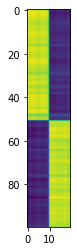

In [22]:
mat = np.array(mat.tolist())
plt.imshow(mat)

In [23]:
pd.DataFrame(mat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.416244,1.303192,1.397497,1.336456,1.313493,1.246580,1.337726,1.310426,1.327907,1.235414,-1.326783,-1.307255,-1.335764,-1.262780,-1.236437,-1.264168,-1.232649,-1.326064,-1.168630,-1.259710
1,1.648508,1.511932,1.622178,1.542383,1.516893,1.474958,1.527321,1.510845,1.533064,1.416630,-1.536478,-1.498807,-1.527462,-1.470701,-1.419391,-1.467088,-1.484193,-1.515817,-1.454628,-1.462294
2,1.600578,1.470828,1.577597,1.505131,1.479673,1.418356,1.499985,1.475221,1.495722,1.387699,-1.496330,-1.468315,-1.498733,-1.427468,-1.389480,-1.426956,-1.412740,-1.487629,-1.358276,-1.422074
3,1.530159,1.408640,1.510470,1.445617,1.420651,1.343843,1.449065,1.417648,1.436301,1.337469,-1.434494,-1.415270,-1.446641,-1.364248,-1.338378,-1.366404,-1.325598,-1.436205,-1.250786,-1.361537
4,1.475605,1.359547,1.457639,1.397078,1.372722,1.290510,1.404149,1.370387,1.387951,1.294629,-1.385139,-1.369984,-1.401263,-1.315422,-1.295151,-1.318686,-1.267150,-1.391279,-1.184824,-1.313902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.471639,-1.355189,-1.453085,-1.391451,-1.367336,-1.290425,-1.396166,-1.364657,-1.382438,-1.288127,1.380301,1.363075,1.393630,1.312004,1.288869,1.314520,1.270724,1.383623,1.194973,1.309805
96,-1.498966,-1.377332,-1.477334,-1.409255,-1.385443,-1.328899,-1.404031,-1.381213,-1.400458,-1.299079,1.401144,1.374542,1.402918,1.336866,1.300786,1.336259,1.324261,1.392510,1.274354,1.331697
97,-1.457270,-1.343694,-1.440468,-1.382485,-1.358174,-1.269477,-1.392922,-1.356385,-1.373340,-1.283009,1.369577,1.357729,1.389565,1.298905,1.283196,1.303220,1.241094,1.379780,1.150406,1.298413
98,-1.400162,-1.288709,-1.381913,-1.322117,-1.299337,-1.230911,-1.324418,-1.296461,-1.313626,-1.222737,1.312216,1.293854,1.322326,1.248389,1.223650,1.250091,1.215530,1.312758,1.149396,1.245658


In [24]:
lrnr.weight

<bound method EmbeddingDotBias.weight of EmbeddingDotBias(
  (u_weight): Embedding(101, 2)
  (i_weight): Embedding(21, 2)
  (u_bias): Embedding(101, 1)
  (i_bias): Embedding(21, 1)
)>

In [32]:
lrnr

In [29]:
net=lrnr.model

In [36]:
lrnr.loss_func

FlattenedLoss of MSELoss()

In [38]:
x,y = dls.one_batch()

In [74]:
x[[0,1,2,3]],y[[0,1,2,3]]

(tensor([[14, 11],
         [74, 11],
         [97, 15],
         [81, 11]]),
 tensor([[1.0972],
         [4.3032],
         [3.8258],
         [3.7104]]))

In [132]:
matdf.iloc[13,:]

커피0        None
커피1    3.919329
커피2        None
커피3        None
커피4    4.223302
커피5        None
커피6    4.068005
커피7        None
커피8        None
커피9        None
홍차0    1.097195
홍차1        None
홍차2        None
홍차3        None
홍차4        None
홍차5        None
홍차6    0.843055
홍차7        None
홍차8        None
홍차9    1.441432
Name: 13, dtype: object

In [99]:
lrnr.model(x[[0,1,2,3]].to("cuda:0"))

tensor([1.0798, 4.0437, 3.9457, 3.7488], device='cuda:0',
       grad_fn=<AddBackward0>)

In [114]:
lrnr.model(torch.tensor([[14,8]]).to("cuda:0"))

tensor([4.0368], device='cuda:0', grad_fn=<AddBackward0>)

### 7번유저의 취향? 

In [120]:
[[7,i] for i in range(20)]

[[7, 0],
 [7, 1],
 [7, 2],
 [7, 3],
 [7, 4],
 [7, 5],
 [7, 6],
 [7, 7],
 [7, 8],
 [7, 9],
 [7, 10],
 [7, 11],
 [7, 12],
 [7, 13],
 [7, 14],
 [7, 15],
 [7, 16],
 [7, 17],
 [7, 18],
 [7, 19]]

In [121]:
torch.tensor([[7,i] for i in range(20)])

tensor([[ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 7,  3],
        [ 7,  4],
        [ 7,  5],
        [ 7,  6],
        [ 7,  7],
        [ 7,  8],
        [ 7,  9],
        [ 7, 10],
        [ 7, 11],
        [ 7, 12],
        [ 7, 13],
        [ 7, 14],
        [ 7, 15],
        [ 7, 16],
        [ 7, 17],
        [ 7, 18],
        [ 7, 19]])

In [122]:
lrnr.model(torch.tensor([[7,i] for i in range(20)]).to("cuda:0"))

tensor([2.3847, 3.9071, 3.7139, 3.9309, 3.7588, 3.8483, 3.7608, 3.8850, 3.8347,
        3.8281, 3.7454, 0.9696, 0.9547, 0.9890, 1.0613, 1.0015, 1.0910, 1.1039,
        0.9614, 1.1641], device='cuda:0', grad_fn=<AddBackward0>)

In [85]:
torch.tensor([[0,2]],dtype=torch.int64).to("cuda:0")

tensor([[0, 2]], device='cuda:0')

In [90]:
lrnr.model(torch.tensor([[0,2]]).to("cuda:0"))

tensor([2.4144], device='cuda:0', grad_fn=<AddBackward0>)

### 영화추천 

In [ ]:
path = untar_data(URLs.ML_100k) 

In [ ]:
ratings = pd.read_csv(path/'u.data',delimiter='\t', header=None, 
                      names=['user','movie','rating','timestamp']) 
ratings.head()

In [ ]:
movies=pd.read_csv(path/'u.item',delimiter='|', encoding='latin-1',usecols=(0,1),names=('movie','title'),header=None)

In [ ]:
movies.head()

In [ ]:
ratings = ratings.merge(movies)
ratings

In [ ]:
X = ratings[['user','movie']].values

In [ ]:
X

In [ ]:
Y = ratings[["rating"]].values

In [ ]:
Y

In [ ]:
max_user, max_item = X.max(0)

In [ ]:
max_user, max_item

In [ ]:
user_emb=nn.Embedding(944,20,0)

In [ ]:
item_emb=nn.Embedding(1682,20,0)

In [ ]:
X[0]

In [ ]:
user_emb(X[0])

In [ ]:
nn.Embedding(944,20,0) * nn.Embedding(1682,20,0)

In [ ]:
dls=CollabDataLoaders.from_df(ratings,item_name='title',bs=64)

In [ ]:
dls.show_batch()

`-` 편향이 필요한 이유: 어떤영화는 그냥 재미없을수도.. 어떤사람은 그냥 점수를 높게 줄수도 있어.. 

In [ ]:
lrnr = collab_learner(dls,n_factors=50,y_range=(0.5,5))

In [ ]:
lrnr.fit_one_cycle(5)

In [ ]:
lrnr.model.i_bias.weight.squeeze()

In [ ]:
lrnr.model.i_bias.weight.squeeze().argsort()[:5]

In [ ]:
dls.classes['title'][295]

In [ ]:
dls.classes['title'][855]

In [ ]:
dls.classes['title'][357]

In [ ]:
dls.classes['title'][62]

In [ ]:
dls.classes['title'][850]

In [ ]:
lrnr.model.i_bias.weight.squeeze().argsort(descending=True)[:5]

In [ ]:
dls.classes['title'][1501]

In [ ]:
dls.classes['title'][830]

In [ ]:
dls.classes['title'][319]

In [ ]:
dls.classes['title'][93]

In [ ]:
dls.classes['title'][1318]